In [ ]:
# ============================================
# Stage-1 Dataset Preparation (Balanced)
# Normal vs Pneumonia (5000 vs 5000)
# ============================================

import os
import random
import shutil
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Paths
BASE_DIR = "/content/drive/MyDrive/stage1_dataset"
OLD_DATASET = "/content/drive/MyDrive/Pneumonia_ReBalanced_Dataset"   # old dataset path

normal_src = os.path.join(OLD_DATASET, "Normal")
bacterial_src = os.path.join(OLD_DATASET, "Bacterial Pneumonia")
viral_src = os.path.join(OLD_DATASET, "Viral Pneumonia")

normal_dst = os.path.join(BASE_DIR, "Normal")
pneumonia_dst = os.path.join(BASE_DIR, "Pneumonia")

# Step 3: Create new directories
os.makedirs(normal_dst, exist_ok=True)
os.makedirs(pneumonia_dst, exist_ok=True)

# Step 4: Copy all Normal images (5000 expected)
print("Copying Normal images...")
for i, fname in enumerate(os.listdir(normal_src)):
    src_path = os.path.join(normal_src, fname)
    dst_path = os.path.join(normal_dst, f"Normal_{i+1}.jpg")
    shutil.copy(src_path, dst_path)
print(f" Copied {len(os.listdir(normal_dst))} Normal images.")

# Step 5: Randomly sample 2500 Bacterial + 2500 Viral
print("Sampling Pneumonia images...")
bacterial_files = os.listdir(bacterial_src)
viral_files = os.listdir(viral_src)

random.seed(42)  # reproducibility
bacterial_sample = random.sample(bacterial_files, 2500)
viral_sample = random.sample(viral_files, 2500)

all_pneumonia = bacterial_sample + viral_sample
random.shuffle(all_pneumonia)

# Step 6: Copy and rename to Pneumonia_1...Pneumonia_5000
for i, fname in enumerate(all_pneumonia):
    if fname in bacterial_sample:
        src_path = os.path.join(bacterial_src, fname)
    else:
        src_path = os.path.join(viral_src, fname)
    dst_path = os.path.join(pneumonia_dst, f"Pneumonia_{i+1}.jpg")
    shutil.copy(src_path, dst_path)
print(f" Copied {len(os.listdir(pneumonia_dst))} Pneumonia images.")

print("\n Stage-1 dataset ready at:", BASE_DIR)
print("Structure:")
print(" -", normal_dst)
print(" -", pneumonia_dst)


Mounted at /content/drive
Copying Normal images...
 Copied 5000 Normal images.
Sampling Pneumonia images...
 Copied 5000 Pneumonia images.

 Stage-1 dataset ready at: /content/drive/MyDrive/stage1_dataset
Structure:
 - /content/drive/MyDrive/stage1_dataset/Normal
 - /content/drive/MyDrive/stage1_dataset/Pneumonia


In [ ]:
# ============================================
# Stage-1 Dataset Splitting (Train/Test)
# Train: 4900 Normal + 4900 Pneumonia
# Test : 100 Normal + 100 Pneumonia
# ============================================

import os
import random
import shutil
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Paths
BASE_DIR = "/content/drive/MyDrive/stage1_dataset"
NEW_SPLIT_DIR = "/content/drive/MyDrive/stage1_dataset_splitted"

normal_src = os.path.join(BASE_DIR, "Normal")
pneumonia_src = os.path.join(BASE_DIR, "Pneumonia")

train_normal_dst = os.path.join(NEW_SPLIT_DIR, "train", "Normal")
train_pneumonia_dst = os.path.join(NEW_SPLIT_DIR, "train", "Pneumonia")
test_normal_dst = os.path.join(NEW_SPLIT_DIR, "test", "Normal")
test_pneumonia_dst = os.path.join(NEW_SPLIT_DIR, "test", "Pneumonia")

# Step 3: Create directories
for path in [train_normal_dst, train_pneumonia_dst, test_normal_dst, test_pneumonia_dst]:
    os.makedirs(path, exist_ok=True)

# Step 4: Split Normal images
normal_files = os.listdir(normal_src)
random.shuffle(normal_files)

test_normal = normal_files[:100]   # 100 test
train_normal = normal_files[100:]  # 4900 train

for i, fname in enumerate(train_normal):
    shutil.copy(os.path.join(normal_src, fname), os.path.join(train_normal_dst, f"Normal_{i+1}.jpg"))

for i, fname in enumerate(test_normal):
    shutil.copy(os.path.join(normal_src, fname), os.path.join(test_normal_dst, f"Normal_{i+1}.jpg"))

print(f" Normal -> Train: {len(os.listdir(train_normal_dst))}, Test: {len(os.listdir(test_normal_dst))}")

# Step 5: Split Pneumonia images
pneumonia_files = os.listdir(pneumonia_src)
random.shuffle(pneumonia_files)

test_pneumonia = pneumonia_files[:100]   # 100 test
train_pneumonia = pneumonia_files[100:]  # 4900 train

for i, fname in enumerate(train_pneumonia):
    shutil.copy(os.path.join(pneumonia_src, fname), os.path.join(train_pneumonia_dst, f"Pneumonia_{i+1}.jpg"))

for i, fname in enumerate(test_pneumonia):
    shutil.copy(os.path.join(pneumonia_src, fname), os.path.join(test_pneumonia_dst, f"Pneumonia_{i+1}.jpg"))

print(f" Pneumonia -> Train: {len(os.listdir(train_pneumonia_dst))}, Test: {len(os.listdir(test_pneumonia_dst))}")

# Step 6: Summary
print("\n Splitting completed! New dataset saved at:", NEW_SPLIT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Normal -> Train: 4900, Test: 100
 Pneumonia -> Train: 4900, Test: 100

 Splitting completed! New dataset saved at: /content/drive/MyDrive/stage1_dataset_splitted


In [ ]:
from google.colab import drive

# Google Drive mount karo
drive.mount('/content/drive')

print(" Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted successfully!


In [ ]:
import shutil
import os

#  Drive se dataset ka path
drive_dataset_path = "/content/drive/MyDrive/stage1_dataset_splitted"

#  Colab local storage path
local_dataset_path = "/content/stage1_dataset_splitted"

# Agar pehle se local me hai to fresh copy ke liye delete kar do
shutil.rmtree(local_dataset_path, ignore_errors=True)

#  Copy from Drive to local
shutil.copytree(drive_dataset_path, local_dataset_path)

print(" Dataset copied to local Colab storage:", local_dataset_path)

#  Structure check
for root, dirs, files in os.walk(local_dataset_path):
    level = root.replace(local_dataset_path, "").count(os.sep)
    indent = " " * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:  # Only show 5 files of every folder
        print(f"{subindent}{f}")


 Dataset copied to local Colab storage: /content/stage1_dataset_splitted
stage1_dataset_splitted/
    test/
        Normal/
            Normal_12.jpg
            Normal_17.jpg
            Normal_67.jpg
            Normal_1.jpg
            Normal_36.jpg
        Pneumonia/
            Pneumonia_95.jpg
            Pneumonia_52.jpg
            Pneumonia_85.jpg
            Pneumonia_82.jpg
            Pneumonia_64.jpg
    train/
        Normal/
            Normal_294.jpg
            Normal_1781.jpg
            Normal_990.jpg
            Normal_119.jpg
            Normal_2886.jpg
        Pneumonia/
            Pneumonia_2242.jpg
            Pneumonia_3053.jpg
            Pneumonia_4485.jpg
            Pneumonia_264.jpg
            Pneumonia_3308.jpg


In [ ]:
# ============================================
# Pneumonia Stage-1 training: EfficientNetB0
# Classes: Normal vs Pneumonia
# Target: Balanced dataset (5000 vs 5000)
# ============================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

# =========================
# Step 1: Mount Google Drive
# =========================
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(BASE_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage1_norm_vs_pneu.keras")

# New Stage-1 Dataset (already split into train/test)
DATASET_DIR = "/content/stage1_dataset_splitted/train"
TEST_DIR = "/content/stage1_dataset_splitted/test"

# =========================
# Step 2: Data Preprocessing
# =========================
IMG_SIZE = (224, 224)   # EfficientNetB0 default input size
BATCH_SIZE = 16

classes_to_use = ['Normal', 'Pneumonia']

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    classes=classes_to_use
)

print("Class indices:", train_generator.class_indices)

# Class Weights
labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

# =========================
# Step 3: Build EfficientNetB0 Model
# =========================
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# =========================
# Step 4: Training Phase 1 (Frozen Base) - 20 epochs
# =========================
callbacks = [
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='loss', mode='min', verbose=1),
    EarlyStopping(monitor='loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_generator,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

# =========================
# Step 5: Fine-Tuning Phase 2 (Unfreeze last 50 layers) - 40 epochs
# =========================
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_generator,
    epochs=40,
    callbacks=callbacks,
    class_weight=class_weights
)

# =========================
# Step 6: Save Final Model
# =========================
model.save(MODEL_PATH)
print(f"Model saved at {MODEL_PATH}")

# =========================
# Step 7: Print Last Conv Layer (For Grad-CAM)
# =========================
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last Conv Layer for Grad-CAM:", layer.name)
        break

# =========================
# Step 8: Evaluate on Test Set
# =========================
if os.path.exists(TEST_DIR):
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=classes_to_use
    )

    loss, acc = model.evaluate(test_generator, verbose=1)
    print("Test loss:", loss, "Test accuracy:", acc)

    from sklearn.metrics import confusion_matrix, classification_report
    y_true = test_generator.classes
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))
else:
    print("Test folder not found at:", TEST_DIR)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 9800 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Pneumonia': 1}
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,021 (16.70 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7998 - loss: 0.4123
Epoch 1: loss improved from inf to 0.32576, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage1_norm_vs_pneu.keras
613/613 ━━━━━━━━━━━━━━━━━━━━ 182s 251ms/step - accuracy: 0.7999 - loss: 0.4122 - learning_rate: 1.0000e-04
Epoch 2/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8990 - loss: 0.2449
Epoch 2: loss improved from 0.32576 to 0.23322, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage1_norm_vs_pneu.keras
613/613 ━━━━━━━━━━━━━━━━━━━━ 137s 224ms/step - accuracy: 0.8990 - loss: 0.2448 - learning_rate: 1.0000e-04
Epoch 3/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9184 - loss: 0.2066
Epoch 3: loss improved from 0.23322 to 0.20612, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage1_norm_vs_pneu.keras
613/613 ━━━━━━━━━━━━━━━━━━━━ 136s 222ms/ste

In [ ]:
from google.colab import drive

# Google Drive mount karo
drive.mount('/content/drive')

print(" Drive mounted successfully!")

Mounted at /content/drive
 Drive mounted successfully!


In [ ]:
# --- Install libs (agar chahiye ho) ---
!pip install -q opencv-python-headless

# --- Imports ---
import os
import numpy as np
import cv2
from PIL import Image
from google.colab import files

import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

# ---------------------------
# === CONFIG ===
MODEL_PATH = "/content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage1_norm_vs_pneu.keras"
IMG_SIZE = (224, 224)
CLASS_NAMES = ["Normal", "Pneumonia"]

# ---------------------------
# 1) Load Model
model = tf.keras.models.load_model(MODEL_PATH)
print(" Model loaded from:", MODEL_PATH)

# ---------------------------
# 2) Upload image
print(" Upload an X-ray image...")
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit(" No file uploaded — stopping.")
image_filename = list(uploaded.keys())[0]
uploaded_path = os.path.join("/content", image_filename)
print("Uploaded:", image_filename)

# ---------------------------
# 3) Image Validation Functions
def heuristic_validate(image_path, min_mean=20, max_mean=230, min_var=100, edge_threshold=0.0008):
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return False, " Could not read as image"
        if img_bgr.ndim == 2:
            img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)

        h, w = img_bgr.shape[:2]
        if h < 100 or w < 100:
            return False, f" Image too small ({w}x{h})"

        resized = cv2.resize(img_bgr, IMG_SIZE)
        mean_pix = float(np.mean(resized))
        if mean_pix < min_mean or mean_pix > max_mean:
            return False, f" Brightness out of range (mean={mean_pix:.1f})"

        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        var = float(np.var(gray))
        if var < min_var:
            return False, f" Low variance: {var:.1f}"

        edges = cv2.Canny(gray, 50, 150)
        edge_density = edges.sum() / (IMG_SIZE[0]*IMG_SIZE[1]*255.0)
        if edge_density < edge_threshold:
            return False, " Low edge density (not X-ray-like)"

        return True, " Heuristic checks passed"
    except Exception as e:
        return False, f" Validation error: {e}"

# ---------------------------
# 4) Run Validation
ok, msg = heuristic_validate(uploaded_path)
print("Validation:", msg)
if not ok:
    raise SystemExit(" Stopping pipeline: invalid image.")

# ---------------------------
# 5) Preprocess & Predict
img = load_img(uploaded_path, target_size=IMG_SIZE, color_mode="grayscale")
x = img_to_array(img)  # (224,224,1)

# Grayscale → RGB
x = np.repeat(x, 3, axis=-1)  # (224,224,3)

# Batch dimension
x = np.expand_dims(x, axis=0)

# Preprocess
x = preprocess_input(x)

# Predict
preds = model.predict(x, verbose=0)
confidence = float(np.max(preds) * 100)
pred_class_index = int(np.argmax(preds))
pred_class = CLASS_NAMES[pred_class_index]

print(f" Prediction: {pred_class} ({confidence:.2f}%)")


 Model loaded from: /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage1_norm_vs_pneu.keras
 Upload an X-ray image...


Saving Viral Pneumonia (32).jpg to Viral Pneumonia (32).jpg
Uploaded: Viral Pneumonia (32).jpg
Validation:  Heuristic checks passed
 Prediction: Pneumonia (99.71%)


In [ ]:
# ============================================
# Fixing Stage-1 EfficientNetB0 model
# (Load old model and re-save in keras format)
# ============================================

import os
import tensorflow as tf
from google.colab import drive

# =========================
# Step 1: Mount Google Drive
# =========================
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(BASE_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

# Old model path (jisne error diya tha)
OLD_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage1_norm_vs_pneu.keras")

# New fixed model path
NEW_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage1_norm_vs_pneu_fixed.keras")

# =========================
# Step 2: Load Model Safely
# =========================
print(" Loading old model...")
model = tf.keras.models.load_model(OLD_MODEL_PATH)

print("\nModel loaded successfully! ")
model.summary()

# =========================
# Step 3: Re-save in Correct Keras Format
# =========================
print(f"\n Saving fixed model at: {NEW_MODEL_PATH}")
model.save(NEW_MODEL_PATH, save_format="keras")
print(" Fixed model saved successfully!")

# =========================
# Step 4: Verify Reload
# =========================
print("\n Verifying reload...")
fixed_model = tf.keras.models.load_model(NEW_MODEL_PATH)
print("Reloaded model summary:")
fixed_model.summary()

# =========================
# Step 5: Last Conv Layer (for Grad-CAM)
# =========================
for layer in reversed(fixed_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last Conv Layer for Grad-CAM:", layer.name)
        break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Loading old model...

Model loaded successfully! 


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 11,991,187 (45.74 MB)

 Trainable params: 3,806,582 (14.52 MB)

...

 Total params: 11,991,187 (45.74 MB)

 Trainable params: 3,806,582 (14.52 MB)

 Non-trainable params: 571,439 (2.18 MB)

 Optimizer params: 7,613,166 (29.04 MB)

Last Conv Layer for Grad-CAM: top_conv


In [ ]:
# ======================================================
# Stage-2 Dataset Preparation (Bacterial vs Viral)
# ======================================================

import os
import shutil
import random
from google.colab import drive

# Step 1: Mount Drive
drive.mount('/content/drive')

# Step 2: Define Paths
BASE_DIR = "/content/drive/MyDrive"
SOURCE_DATASET = os.path.join(BASE_DIR, "Pneumonia_ReBalanced_Dataset")  # original dataset
STAGE2_DATASET = os.path.join(BASE_DIR, "Pneumonia_Stage2_Dataset")     # new dataset for stage-2

# Step 3: Classes we need
CLASSES = ["Bacterial Pneumonia", "Viral Pneumonia"]

# Step 4: Create new dataset folder structure
for split in ["train", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(STAGE2_DATASET, split, cls), exist_ok=True)

# Step 5: Function to split and copy images
def split_and_copy(class_name, train_count=4900, test_count=100):
    source_folder = os.path.join(SOURCE_DATASET, class_name)
    images = os.listdir(source_folder)
    random.shuffle(images)

    # Ensure enough images exist
    assert len(images) >= (train_count + test_count), f"Not enough images in {class_name}"

    # Split images
    train_images = images[:train_count]
    test_images = images[train_count:train_count+test_count]

    # Copy train images
    for img in train_images:
        src = os.path.join(source_folder, img)
        dst = os.path.join(STAGE2_DATASET, "train", class_name, img)
        shutil.copy(src, dst)

    # Copy test images
    for img in test_images:
        src = os.path.join(source_folder, img)
        dst = os.path.join(STAGE2_DATASET, "test", class_name, img)
        shutil.copy(src, dst)

    print(f"{class_name}: {len(train_images)} train + {len(test_images)} test copied successfully!")

# Step 6: Run for both classes
for cls in CLASSES:
    split_and_copy(cls)

print("\n Stage-2 Dataset ready at:", STAGE2_DATASET)


Mounted at /content/drive
Bacterial Pneumonia: 4900 train + 100 test copied successfully!
Viral Pneumonia: 4900 train + 100 test copied successfully!

 Stage-2 Dataset ready at: /content/drive/MyDrive/Pneumonia_Stage2_Dataset


In [ ]:
# ======================================================
# Check Stage-2 Dataset Distribution
# ======================================================

import os
from google.colab import drive

# Step 1: Mount Drive
drive.mount('/content/drive')

# Step 2: Define Dataset Path
STAGE2_DATASET = "/content/drive/MyDrive/Pneumonia_Stage2_Dataset"

# Step 3: Walk through dataset and count images
for split in ["train", "test"]:
    print(f"\n=== {split.upper()} DATA ===")
    split_path = os.path.join(STAGE2_DATASET, split)
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"{cls}: {count} images")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== TRAIN DATA ===
Bacterial Pneumonia: 4900 images
Viral Pneumonia: 4900 images

=== TEST DATA ===
Bacterial Pneumonia: 100 images
Viral Pneumonia: 100 images


In [ ]:
from google.colab import drive

# Google Drive mount karo
drive.mount('/content/drive')

print(" Drive mounted successfully!")

Mounted at /content/drive
 Drive mounted successfully!


In [ ]:
import shutil
import os

#  Drive se dataset ka path
drive_dataset_path = "/content/drive/MyDrive/Pneumonia_Stage2_Dataset"

#  Colab local storage path
local_dataset_path = "/content/Pneumonia_Stage2_Dataset"

# Agar pehle se local me hai to fresh copy ke liye delete kar do
shutil.rmtree(local_dataset_path, ignore_errors=True)

#  Copy from Drive to local
shutil.copytree(drive_dataset_path, local_dataset_path)

print(" Dataset copied to local Colab storage:", local_dataset_path)

 Dataset copied to local Colab storage: /content/Pneumonia_Stage2_Dataset


In [ ]:
# ============================================
# Pneumonia Stage-2 training: EfficientNetB0
# Classes: Bacterial vs Viral
# Target: Balanced dataset (4900 vs 4900 train, 100 vs 100 test)
# ============================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# =========================
# Step 1: Mount Google Drive
# =========================
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(BASE_DIR, "model")
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage2_bac_vs_vir.keras")

# Stage-2 Dataset
DATASET_DIR = "/content/Pneumonia_Stage2_Dataset/train"
TEST_DIR = "/content/Pneumonia_Stage2_Dataset/test"

# =========================
# Step 2: Data Preprocessing
# =========================
IMG_SIZE = (224, 224)   # EfficientNetB0 input size
BATCH_SIZE = 16

classes_to_use = ['Bacterial Pneumonia', 'Viral Pneumonia']

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.02,  # 02% of training as validation
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

# Training set
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset="training",
    shuffle=True,
    classes=classes_to_use
)

# Validation set
val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset="validation",
    shuffle=True,
    classes=classes_to_use
)

print("Class indices:", train_generator.class_indices)

# Class Weights
labels = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

# =========================
# Step 3: Build EfficientNetB0 Model
# =========================
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# =========================
# Step 4: Training Phase 1 (Frozen Base)
# =========================
callbacks = [
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weights
)

# =========================
# Step 5: Fine-Tuning Phase 2 (Unfreeze last 100 layers)
# =========================
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weights
)

# =========================
# Step 6: Save Final Model (safe format)
# =========================
model.save(MODEL_PATH, save_format="keras")
print(f" Final Stage-2 Model saved at {MODEL_PATH}")

# =========================
# Step 7: Print Last Conv Layer (For Grad-CAM)
# =========================
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Last Conv Layer for Grad-CAM:", layer.name)
        break

# =========================
# Step 8: Evaluate on Test Set
# =========================
if os.path.exists(TEST_DIR):
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=classes_to_use
    )

    loss, acc = model.evaluate(test_generator, verbose=1)
    print("Test loss:", loss, "Test accuracy:", acc)

    y_true = test_generator.classes
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))
else:
    print(" Test folder not found at:", TEST_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 9604 images belonging to 2 classes.
Found 196 images belonging to 2 classes.
Class indices: {'Bacterial Pneumonia': 0, 'Viral Pneumonia': 1}
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,021 (16.70 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6403 - loss: 0.6476
Epoch 1: val_loss improved from inf to 0.52328, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage2_bac_vs_vir.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 197s 281ms/step - accuracy: 0.6403 - loss: 0.6476 - val_accuracy: 0.7500 - val_loss: 0.5233 - learning_rate: 1.0000e-04
Epoch 2/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7260 - loss: 0.5560
Epoch 2: val_loss improved from 0.52328 to 0.52030, saving model to /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage2_bac_vs_vir.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 142s 236ms/step - accuracy: 0.7260 - loss: 0.5560 - val_accuracy: 0.7347 - val_loss: 0.5203 - learning_rate: 1.0000e-04
Epoch 3/20
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7381 - loss: 0.5470
Epoch 3: val_loss improved from 0.52030 to 0.47995, saving model to /content/drive/MyDrive/pneumonia_detection_syste

 Final Stage-2 Model saved at /content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage2_bac_vs_vir.keras
Last Conv Layer for Grad-CAM: top_conv
Found 200 images belonging to 2 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 864ms/step - accuracy: 0.8532 - loss: 0.3272
Test loss: 0.2630770206451416 Test accuracy: 0.8949999809265137
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 609ms/step
Confusion Matrix:
[[86 14]
 [ 7 93]]
Classification Report:
                     precision    recall  f1-score   support

Bacterial Pneumonia       0.92      0.86      0.89       100
    Viral Pneumonia       0.87      0.93      0.90       100

           accuracy                           0.90       200
          macro avg       0.90      0.90      0.89       200
       weighted avg       0.90      0.90      0.89       200



In [ ]:
import tensorflow as tf
import os

#  Test ke liye path change karo
# Agar tumhare model file Colab me upload hai:
MODEL_PATH = "/content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage2_bac_vs_vir_fixed.keras"  # relative path

# Check agar file exist karti hai
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"File nahi mili: {MODEL_PATH}")

# Load model
model = tf.keras.models.load_model(MODEL_PATH)

# Verify input shape
print("Model input shape:", model.input_shape)


Model input shape: (None, 224, 224, 3)


In [ ]:
fixed_model = tf.keras.models.load_model(NEW_MODEL_PATH)
print("INPUT SHAPE:", fixed_model.input_shape)


INPUT SHAPE: (None, 224, 224, 3)


In [ ]:
# Colab environment
import tensorflow as tf

# Load stage-2 model (RGB, 224x224)
model = tf.keras.models.load_model("/content/drive/MyDrive/pneumonia_detection_system/model/efficientnetb0_stage2_bac_vs_vir.keras")

# Save RGB version for Windows
model.save("/content/drive/MyDrive/pneumonia_detection_system/model/New_efficientnetb0_stage2_bac_vs_vir.keras", save_format="keras")


In [ ]:
import tensorflow as tf

MODEL_PATH = r"/content/drive/MyDrive/pneumonia_detection_system/model/New_efficientnetb0_stage2_bac_vs_vir.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")
print("Model input shape:", model.input_shape)


Model loaded successfully!
Model input shape: (None, 224, 224, 3)


In [ ]:
from google.colab import drive

# Google Drive mount karo
drive.mount('/content/drive')

print(" Drive mounted successfully!")

Mounted at /content/drive
 Drive mounted successfully!


In [ ]:
# ============================================
#  Pneumonia 2-Stage Pipeline Test (Colab)
# Stage 1: EfficientNetB0 (Normal vs Pneumonia)
# Stage 2: EfficientNetB0 (Bacterial vs Viral)
# ============================================

# 1) Install required libs
!pip install -q opencv-python-headless

# 2) Imports
import os
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
import tensorflow as tf

# 3) Config
BASE_DIR = "/content/drive/MyDrive/pneumonia_detection_system/model"

STAGE1_MODEL_PATH = os.path.join(BASE_DIR, "efficientnetb0_stage1_norm_vs_pneu_fixed.keras")
STAGE2_MODEL_PATH = os.path.join(BASE_DIR, "New_efficientnetb0_stage2_bac_vs_vir.keras")

STAGE1_CLASSES = ["Normal", "Pneumonia"]
STAGE2_CLASSES = ["Bacterial Pneumonia", "Viral Pneumonia"]

IMG_SIZE = (224, 224)

# 4) Load both models
print(" Loading Stage 1 model...")
stage1_model = tf.keras.models.load_model(STAGE1_MODEL_PATH)
print(" Stage 1 model loaded!")

print(" Loading Stage 2 model...")
stage2_model = tf.keras.models.load_model(STAGE2_MODEL_PATH)
print(" Stage 2 model loaded!")

# 5) Upload image
print("\n Please upload a Chest X-ray image:")
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit(" No file uploaded.")
filename = list(uploaded.keys())[0]
image_path = os.path.join("/content", filename)
print(f" Uploaded: {filename}")

# 6) Helper: Preprocess for Stage 1
def preprocess_for_stage1(img_path):
    #  Load image in RGB because model was trained on RGB
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    x = img_to_array(img)          # (224,224,3)
    x = np.expand_dims(x, axis=0)  # (1,224,224,3)
    return effnet_preprocess(x)

# 7) Helper: Preprocess for Stage 2
def preprocess_for_stage2(img_path):
    #  Same as Stage 1, both are EfficientNetB0
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    return effnet_preprocess(x)

# 8) Stage 1 Prediction
print("\n Running Stage 1 (Normal vs Pneumonia)...")
x1 = preprocess_for_stage1(image_path)
preds1 = stage1_model.predict(x1, verbose=0)

print(" Raw Stage 1 Prediction:", preds1)
for i, cls in enumerate(STAGE1_CLASSES):
    print(f"  {cls}: {preds1[0][i]*100:.2f}%")

conf1 = float(np.max(preds1) * 100)
label1 = STAGE1_CLASSES[int(np.argmax(preds1))]
print(f"\n Stage 1 Result: {label1} ({conf1:.2f}%)")

# 9) Decision Logic
if label1 == "Normal":
    print("\n Final Diagnosis: X-ray is **Normal** — no further analysis needed.")
else:
    print("\n Pneumonia detected. Sending image to Stage 2 for type classification...")

    # 10) Stage 2 Prediction
    print("\n Running Stage 2 (Bacterial vs Viral)...")
    x2 = preprocess_for_stage2(image_path)
    preds2 = stage2_model.predict(x2, verbose=0)

    print(" Raw Stage 2 Prediction:", preds2)
    for i, cls in enumerate(STAGE2_CLASSES):
        print(f"  {cls}: {preds2[0][i]*100:.2f}%")

    conf2 = float(np.max(preds2) * 100)
    label2 = STAGE2_CLASSES[int(np.argmax(preds2))]

    print(f"\n Final Diagnosis: {label2} ({conf2:.2f}%)")


 Loading Stage 1 model...
 Stage 1 model loaded!
 Loading Stage 2 model...
 Stage 2 model loaded!

 Please upload a Chest X-ray image:


Saving NORMAL (48).jpg to NORMAL (48).jpg
 Uploaded: NORMAL (48).jpg

 Running Stage 1 (Normal vs Pneumonia)...
 Raw Stage 1 Prediction: [[1.000000e+00 2.824963e-09]]
  Normal: 100.00%
  Pneumonia: 0.00%

 Stage 1 Result: Normal (100.00%)

 Final Diagnosis: X-ray is **Normal** — no further analysis needed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/"


Mounted at /content/drive
'Colab Notebooks'		        Pneumonia_Processed.zip
 Pneumonia_80_12_8_Splitted	        Pneumonia_ReBalanced_Dataset
 Pneumonia_80_20_Splitted_Updated.zip   Pneumonia_ReBalanced_Dataset.zip
 Pneumonia_90_10_Splitted	        Pneumonia_Stage2_Dataset
 pneumonia_ai			        Pneumonia_Train_Test_Dataset
'Pneumonia Balanced Dataset.zip'        PneumoniaWeb
'Pneumonia Complete Data.zip'	        stage1_dataset
 pneumonia_detection_system	        stage1_dataset_splitted
 Pneumonia_Processed_Balanced.zip


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Stage-1 model...
Loading Stage-2 model...
CLIP loaded.


Saving person61_virus_118.jpeg to person61_virus_118.jpeg
Uploaded: person61_virus_118.jpeg
Validation passed.


Stage 1: Pneumonia (97.19%)


Stage 2 results: [[0.3081524 0.6918476]]
Final Diagnosis: Viral Pneumonia (69.18%)


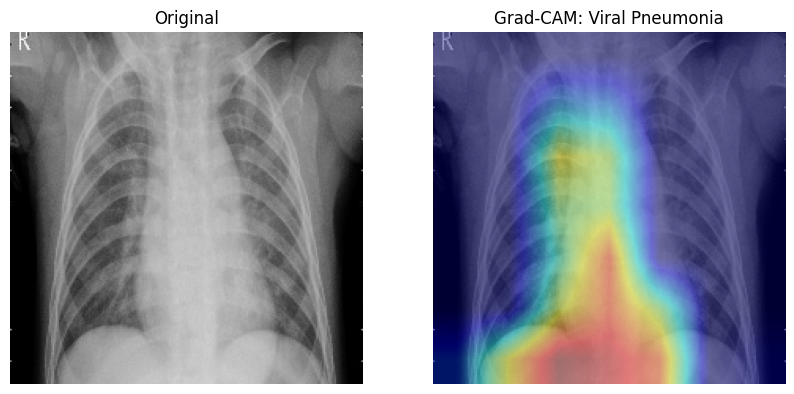


Generated Caption:
 Diagnosis: Viral Pneumonia (confidence 69.2%). Radiographic findings suggest viral pneumonia.

Pipeline finished.


In [ ]:

!pip install -q transformers ftfy opencv-python-headless

import os, time, random
from google.colab import files
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from transformers import CLIPProcessor, CLIPModel

from google.colab import drive
drive.mount('/content/drive')

# ---------------------------
# CONFIG
DRIVE_BASE = "/content/drive/MyDrive/pneumonia_detection_system"
MODEL_DIR = os.path.join(DRIVE_BASE, "model")
HEATMAP_DIR = os.path.join(DRIVE_BASE, "heatmap")
os.makedirs(HEATMAP_DIR, exist_ok=True)

STAGE1_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_stage1_norm_vs_pneu_fixed.keras")
STAGE2_MODEL_PATH = os.path.join(MODEL_DIR, "New_efficientnetb0_stage2_bac_vs_vir.keras")

STAGE1_CLASSES = ["Normal", "Pneumonia"]
STAGE2_CLASSES = ["Bacterial Pneumonia", "Viral Pneumonia"]

IMG_SIZE = (224, 224)
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# ---------------------------
# LOAD MODELS
print("Loading Stage-1 model...")
stage1_model = tf.keras.models.load_model(STAGE1_MODEL_PATH)
print("Loading Stage-2 model...")
stage2_model = tf.keras.models.load_model(STAGE2_MODEL_PATH)

# CLIP
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
print("CLIP loaded.")

# ---------------------------
# UPLOAD IMAGE
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit("No file uploaded.")
filename = list(uploaded.keys())[0]
image_path = os.path.join("/content", filename)
print("Uploaded:", filename)

# ---------------------------
# VALIDATION
def heuristic_validate(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return False, "File not readable"
    h, w = img_bgr.shape[:2]
    if h < 100 or w < 100:
        return False, "Too small"
    return True, "Heuristic check passed"

def clip_modality_check(pil_img):
    prompts = ["This is a chest X-ray image.", "This is a normal photograph."]
    inputs = clip_processor(text=prompts, images=pil_img, return_tensors="pt", padding=True)
    outputs = clip_model(**inputs)
    logits = outputs.logits_per_image.softmax(dim=1).detach().cpu().numpy()[0]
    return logits

valid_ok, note = heuristic_validate(image_path)
pil_img = Image.open(image_path).convert("RGB")
clip_probs = clip_modality_check(pil_img)

if not valid_ok or clip_probs[0] < 0.5:
    raise SystemExit("Validation failed. Not a chest X-ray.")

print("Validation passed.")

# ---------------------------
# PREPROCESS
def preprocess_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    return effnet_preprocess(x)

# ---------------------------
# GRAD-CAM
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return "top_conv"

def generate_gradcam(model, img_array, layer_name=None):
    if layer_name is None:
        layer_name = find_last_conv_layer(model)
    grad_model = tf.keras.models.Model(inputs=model.inputs,
                                       outputs=[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    weighted = conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :]
    heatmap = tf.reduce_sum(weighted, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap(original_path, heatmap):
    orig_bgr = cv2.imread(original_path)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (orig_rgb.shape[1], orig_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(orig_rgb, 0.6, heatmap_color, 0.4, 0)
    return superimposed

# ---------------------------
# CAPTION
def generate_caption(label, conf):
    if label == "Normal":
        return f"Diagnosis: Normal (confidence {conf:.1f}%). No signs of pneumonia."
    elif "Bacterial" in label:
        return f"Diagnosis: {label} (confidence {conf:.1f}%). Radiographic findings suggest bacterial infection."
    else:
        return f"Diagnosis: {label} (confidence {conf:.1f}%). Radiographic findings suggest viral pneumonia."

# ---------------------------
# RUN STAGE 1
x1 = preprocess_image(image_path)
preds1 = stage1_model.predict(x1, verbose=0)
conf1 = float(np.max(preds1) * 100)
label1 = STAGE1_CLASSES[int(np.argmax(preds1))]
print(f"Stage 1: {label1} ({conf1:.2f}%)")

if label1 == "Normal":
    caption = generate_caption(label1, conf1)
    print("\nFinal Diagnosis:", caption)
else:
    # Stage 2
    x2 = preprocess_image(image_path)
    preds2 = stage2_model.predict(x2, verbose=0)
    conf2 = float(np.max(preds2) * 100)
    label2 = STAGE2_CLASSES[int(np.argmax(preds2))]
    print("Stage 2 results:", preds2)
    print(f"Final Diagnosis: {label2} ({conf2:.2f}%)")

    # Grad-CAM
    heatmap = generate_gradcam(stage2_model, x2)
    overlay = overlay_heatmap(image_path, heatmap)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.imshow(load_img(image_path)); plt.axis('off'); plt.title("Original")
    plt.subplot(1,2,2); plt.imshow(overlay); plt.axis('off'); plt.title(f"Grad-CAM: {label2}")
    plt.show()

    caption = generate_caption(label2, conf2)
    print("\nGenerated Caption:\n", caption)

print("\nPipeline finished.")
